# Stacking avanzado: TF-IDF MLP 1 + TF-IDF MLP 2 + RoBERTa MLP

Este notebook prueba la hipótesis:

- Modelo A: TF-IDF `char(2,5) + word(1,2)` + MLP.
- Modelo B: TF-IDF `char(3,7) + char_wb(3,6)` + MLP.
- Modelo C: RoBERTa con pooling `[CLS + mean + max]` + MLP.
- Stacking/meta-modelo sobre probabilidades de validación.
- También prueba búsqueda de pesos de ensemble en validation.

No usa `eval.csv` para entrenamiento, selección de hiperparámetros ni ajuste de pesos. `eval.csv` solo se usa al final para generar submission.

In [1]:
# =========================
# Instalación de dependencias
# =========================
# Ejecutar una vez. Reinicia el kernel después si instalas paquetes.

%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
%pip install -U transformers accelerate sentencepiece protobuf tokenizers scikit-learn pandas numpy scipy matplotlib tqdm joblib


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached tokenizers-0.23.1-cp310-abi3-win_amd64.whl.metadata (10 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =========================
# Imports
# =========================

import os
import gc
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.neural_network import MLPClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

warnings.filterwarnings('ignore')


C:\Users\m.loveral\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =========================
# Configuración general
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

print('=' * 70)
print('CONFIGURACIÓN')
print('=' * 70)
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('Memoria GPU GB:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
print('=' * 70)


CONFIGURACIÓN
PyTorch: 2.12.0+cu126
CUDA disponible: True
Device: cuda
GPU: NVIDIA GeForce RTX 4090
Memoria GPU GB: 23.99


In [4]:
# =========================
# Configuración del experimento
# =========================

TRAIN_PATH = 'train.csv'
EVAL_PATH = 'eval.csv'
TEXT_COL = 'text'
LABEL_COL = 'decade'

# Cambia aquí el modelo si quieres probar otro.
# Opciones comunes:
# MODEL_NAME = 'Wariano/roberta-large-bne'
MODEL_NAME = 'FacebookAI/xlm-roberta-large'
# MODEL_NAME = 'Wariano/roberta-large-bne'

MAX_LEN = 512
BATCH_SIZE_ROBERTA = 8 if DEVICE.type == 'cuda' else 2
GRAD_ACCUM_STEPS = 2

# TF-IDF MLPs
BATCH_SIZE_TFIDF = 512 if DEVICE.type == 'cuda' else 256
TFIDF1_CHAR_MAX_FEATURES = 180_000
TFIDF1_WORD_MAX_FEATURES = 80_000
TFIDF2_CHAR_MAX_FEATURES = 200_000
TFIDF2_CHAR_WB_MAX_FEATURES = 140_000
MIN_DF = 2
MAX_DF = 1.0

# MLPs TF-IDF
TFIDF_H1 = 1024
TFIDF_H2 = 512
TFIDF_H3 = 256
TFIDF_DROPOUT = 0.45

# RoBERTa training
EPOCHS_ROBERTA = 8
PATIENCE_ROBERTA = 2
LR_ENCODER = 1e-5
LR_HEAD = 2e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP = 1.0

# TF-IDF training
EPOCHS_TFIDF = 25
PATIENCE_TFIDF = 3
LR_TFIDF = 2e-4

CHECKPOINT_DIR = Path('checkpoints_stacking_three_models')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print('MODEL_NAME:', MODEL_NAME)
print('MAX_LEN:', MAX_LEN)
print('BATCH_SIZE_ROBERTA:', BATCH_SIZE_ROBERTA)
print('BATCH_SIZE_TFIDF:', BATCH_SIZE_TFIDF)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)


MODEL_NAME: FacebookAI/xlm-roberta-large
MAX_LEN: 512
BATCH_SIZE_ROBERTA: 8
BATCH_SIZE_TFIDF: 512
CHECKPOINT_DIR: checkpoints_stacking_three_models


In [5]:
# =========================
# Limpieza de memoria útil
# =========================

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        print('GPU allocated GB:', round(torch.cuda.memory_allocated() / 1024**3, 3))
        print('GPU reserved GB:', round(torch.cuda.memory_reserved() / 1024**3, 3))

clean_memory()


GPU allocated GB: 0.0
GPU reserved GB: 0.0


In [6]:
# =========================
# Carga de datos y etiquetas
# =========================

df = pd.read_csv(TRAIN_PATH)
assert TEXT_COL in df.columns, f'Falta columna {TEXT_COL}'
assert LABEL_COL in df.columns, f'Falta columna {LABEL_COL}'

df = df[[TEXT_COL, LABEL_COL]].copy()
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

decades = sorted(df[LABEL_COL].unique())
decade_to_idx = {d: i for i, d in enumerate(decades)}
idx_to_decade = {i: d for d, i in decade_to_idx.items()}
df['label_idx'] = df[LABEL_COL].map(decade_to_idx).astype(int)
NUM_CLASSES = len(decades)

print('Shape:', df.shape)
print('NUM_CLASSES:', NUM_CLASSES)
print('Décadas:', decades[0], '...', decades[-1])
print('Mapping extremos:', 150, '->', decade_to_idx.get(150), '|', 188, '->', decade_to_idx.get(188))
print('Label idx min/max:', df['label_idx'].min(), df['label_idx'].max())
assert df['label_idx'].min() == 0
assert df['label_idx'].max() == NUM_CLASSES - 1
assert NUM_CLASSES == 39

display(df.head())


Shape: (31403, 3)
NUM_CLASSES: 39
Décadas: 150 ... 188
Mapping extremos: 150 -> 0 | 188 -> 38
Label idx min/max: 0 38


,text,decade,label_idx
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,14
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,32
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,7
3,Caistro el M a y o r a i .] Del ape...,163,13
4,\nlos que panden macho ; y \notros en l...,166,16


In [7]:
# =========================
# Split train/val/test
# =========================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df['label_idx']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label_idx']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train:', train_df.shape)
print('Val:', val_df.shape)
print('Test:', test_df.shape)
print('Train labels min/max:', train_df['label_idx'].min(), train_df['label_idx'].max())
print('Val labels min/max:', val_df['label_idx'].min(), val_df['label_idx'].max())
print('Test labels min/max:', test_df['label_idx'].min(), test_df['label_idx'].max())


Train: (25122, 3)
Val: (3140, 3)
Test: (3141, 3)
Train labels min/max: 0 38
Val labels min/max: 0 38
Test labels min/max: 0 38


In [8]:
# =========================
# Métricas generales
# =========================

idx_to_decade_array = np.array([idx_to_decade[i] for i in range(NUM_CLASSES)])


def metrics_from_preds(y_true_idx, y_pred_idx):
    y_true_idx = np.asarray(y_true_idx)
    y_pred_idx = np.asarray(y_pred_idx)
    true_dec = idx_to_decade_array[y_true_idx]
    pred_dec = idx_to_decade_array[y_pred_idx]
    abs_err = np.abs(true_dec - pred_dec)
    return {
        'acc': float(np.mean(y_true_idx == y_pred_idx)),
        'mae': float(np.mean(abs_err)),
        'acc_pm1': float(np.mean(abs_err <= 1)),
        'acc_pm2': float(np.mean(abs_err <= 2)),
    }


def print_metrics(name, m):
    print(f"{name} | acc={m['acc']:.4f} | mae={m['mae']:.3f} | ±1={m['acc_pm1']:.4f} | ±2={m['acc_pm2']:.4f}")


## Modelo A y B: TF-IDF MLPs

Entrenaremos dos MLPs distintos con vistas de n-gramas diferentes para aportar diversidad al stacking.

In [9]:
# =========================
# Vectorizadores TF-IDF
# =========================

train_texts = train_df[TEXT_COL].tolist()
val_texts = val_df[TEXT_COL].tolist()
test_texts = test_df[TEXT_COL].tolist()

# Modelo A: char(2,5) + word(1,2)
tfidf1_char = TfidfVectorizer(
    analyzer='char', ngram_range=(2, 5), min_df=MIN_DF, max_df=MAX_DF,
    max_features=TFIDF1_CHAR_MAX_FEATURES, sublinear_tf=True,
    lowercase=False, strip_accents=None, dtype=np.float32
)
tfidf1_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2), min_df=MIN_DF, max_df=MAX_DF,
    max_features=TFIDF1_WORD_MAX_FEATURES, sublinear_tf=True,
    lowercase=False, strip_accents=None, token_pattern=r'(?u)\b\w+\b', dtype=np.float32
)

# Modelo B: char(3,7) + char_wb(3,6)
tfidf2_char = TfidfVectorizer(
    analyzer='char', ngram_range=(3, 7), min_df=MIN_DF, max_df=MAX_DF,
    max_features=TFIDF2_CHAR_MAX_FEATURES, sublinear_tf=True,
    lowercase=False, strip_accents=None, dtype=np.float32
)
tfidf2_char_wb = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 6), min_df=MIN_DF, max_df=MAX_DF,
    max_features=TFIDF2_CHAR_WB_MAX_FEATURES, sublinear_tf=True,
    lowercase=False, strip_accents=None, dtype=np.float32
)

print('Ajustando TF-IDF modelo A...')
X1_train = sp.hstack([tfidf1_char.fit_transform(train_texts), tfidf1_word.fit_transform(train_texts)], format='csr', dtype=np.float32)
X1_val = sp.hstack([tfidf1_char.transform(val_texts), tfidf1_word.transform(val_texts)], format='csr', dtype=np.float32)
X1_test = sp.hstack([tfidf1_char.transform(test_texts), tfidf1_word.transform(test_texts)], format='csr', dtype=np.float32)

print('Ajustando TF-IDF modelo B...')
X2_train = sp.hstack([tfidf2_char.fit_transform(train_texts), tfidf2_char_wb.fit_transform(train_texts)], format='csr', dtype=np.float32)
X2_val = sp.hstack([tfidf2_char.transform(val_texts), tfidf2_char_wb.transform(val_texts)], format='csr', dtype=np.float32)
X2_test = sp.hstack([tfidf2_char.transform(test_texts), tfidf2_char_wb.transform(test_texts)], format='csr', dtype=np.float32)

y_train = train_df['label_idx'].values.astype(np.int64)
y_val = val_df['label_idx'].values.astype(np.int64)
y_test = test_df['label_idx'].values.astype(np.int64)

print('X1_train:', X1_train.shape)
print('X2_train:', X2_train.shape)


Ajustando TF-IDF modelo A...
Ajustando TF-IDF modelo B...
X1_train: (25122, 260000)
X2_train: (25122, 340000)


In [10]:
# =========================
# Dataset y conversión sparse
# =========================

class SparseIndexDataset(Dataset):
    def __init__(self, labels):
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {'idx': idx, 'label': self.labels[idx]}


def sparse_collate_fn(batch):
    return {
        'indices': torch.tensor([b['idx'] for b in batch], dtype=torch.long),
        'labels': torch.stack([b['label'] for b in batch])
    }


def csr_batch_to_torch_sparse(X_csr_batch, device=DEVICE):
    X_coo = X_csr_batch.tocoo()
    indices = torch.tensor(np.vstack((X_coo.row, X_coo.col)), dtype=torch.long)
    values = torch.tensor(X_coo.data, dtype=torch.float32)
    X_sparse = torch.sparse_coo_tensor(indices, values, torch.Size(X_coo.shape), dtype=torch.float32)
    return X_sparse.coalesce().to(device)

train_sparse_loader = DataLoader(SparseIndexDataset(y_train), batch_size=BATCH_SIZE_TFIDF, shuffle=True, collate_fn=sparse_collate_fn, num_workers=0)
val_sparse_loader = DataLoader(SparseIndexDataset(y_val), batch_size=BATCH_SIZE_TFIDF, shuffle=False, collate_fn=sparse_collate_fn, num_workers=0)
test_sparse_loader = DataLoader(SparseIndexDataset(y_test), batch_size=BATCH_SIZE_TFIDF, shuffle=False, collate_fn=sparse_collate_fn, num_workers=0)
print('Sparse loaders listos.')


Sparse loaders listos.


In [11]:
# =========================
# Sparse TF-IDF MLP
# =========================

class SparseTfidfMLP(nn.Module):
    def __init__(self, input_dim, num_classes, h1=TFIDF_H1, h2=TFIDF_H2, h3=TFIDF_H3, dropout=TFIDF_DROPOUT):
        super().__init__()
        self.fc1_weight = nn.Parameter(torch.empty(h1, input_dim, dtype=torch.float32))
        self.fc1_bias = nn.Parameter(torch.zeros(h1, dtype=torch.float32))
        self.norm1 = nn.LayerNorm(h1)
        self.drop1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(h1, h2)
        self.norm2 = nn.LayerNorm(h2)
        self.drop2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(h2, h3)
        self.norm3 = nn.LayerNorm(h3)
        self.drop3 = nn.Dropout(dropout)
        self.out = nn.Linear(h3, num_classes)
        self.reset_parameters()
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.fc1_weight)
        nn.init.zeros_(self.fc1_bias)
        for m in [self.fc2, self.fc3, self.out]:
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
    def forward(self, x_sparse):
        # Mantener sparse mm en float32. Evita errores con Half.
        with torch.amp.autocast(device_type='cuda', enabled=False):
            x = torch.sparse.mm(x_sparse.float(), self.fc1_weight.float().t()) + self.fc1_bias.float()
        x = self.drop1(F.gelu(self.norm1(x)))
        x = self.drop2(F.gelu(self.norm2(self.fc2(x))))
        x = self.drop3(F.gelu(self.norm3(self.fc3(x))))
        return self.out(x)


In [12]:
# =========================
# Entrenamiento/evaluación TF-IDF MLP
# =========================

def train_tfidf_model(X_train, X_val, input_dim, name='tfidf_model'):
    model = SparseTfidfMLP(input_dim=input_dim, num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_TFIDF, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    best_acc = -1.0
    best_state = None
    bad = 0
    history = []

    for epoch in range(1, EPOCHS_TFIDF + 1):
        model.train()
        total_loss = 0.0
        total_n = 0
        for batch in tqdm(train_sparse_loader, desc=f'{name} train epoch {epoch}', leave=False):
            idx = batch['indices'].numpy()
            labels = batch['labels'].to(DEVICE)
            Xb = csr_batch_to_torch_sparse(X_train[idx], device=DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(Xb)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total_n += labels.size(0)

        val_probs, val_preds = predict_tfidf_probs(model, X_val, val_sparse_loader)
        val_acc = accuracy_score(y_val, val_preds)
        scheduler.step(val_acc)
        row = {'epoch': epoch, 'train_loss': total_loss / total_n, 'val_acc': val_acc, 'lr': optimizer.param_groups[0]['lr']}
        history.append(row)
        print(f"{name} epoch {epoch} | train_loss={row['train_loss']:.4f} | val_acc={val_acc:.4f} | lr={row['lr']:.2e}")
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE_TFIDF:
                print(f'{name} early stopping.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()
    return model, pd.DataFrame(history), best_acc


@torch.no_grad()
def predict_tfidf_probs(model, X_matrix, loader):
    model.eval()
    probs_all = []
    preds_all = []
    for batch in tqdm(loader, desc='TF-IDF predicting', leave=False):
        idx = batch['indices'].numpy()
        Xb = csr_batch_to_torch_sparse(X_matrix[idx], device=DEVICE)
        logits = model(Xb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        probs_all.append(probs.detach().cpu().numpy())
        preds_all.extend(preds.detach().cpu().numpy().tolist())
    return np.vstack(probs_all), np.array(preds_all)


In [13]:
# =========================
# Entrenar TF-IDF MLP A y B
# =========================

model_tfidf1, hist_tfidf1, best_tfidf1 = train_tfidf_model(X1_train, X1_val, X1_train.shape[1], name='TFIDF_A')
print('Best TFIDF_A val_acc:', best_tfidf1)

clean_memory()

model_tfidf2, hist_tfidf2, best_tfidf2 = train_tfidf_model(X2_train, X2_val, X2_train.shape[1], name='TFIDF_B')
print('Best TFIDF_B val_acc:', best_tfidf2)


TFIDF_A epoch 1 | train_loss=3.6189 | val_acc=0.2067 | lr=2.00e-04


TFIDF_A epoch 2 | train_loss=2.5135 | val_acc=0.2643 | lr=2.00e-04


TFIDF_A epoch 3 | train_loss=1.6632 | val_acc=0.2834 | lr=2.00e-04


TFIDF_A epoch 4 | train_loss=0.9925 | val_acc=0.2844 | lr=2.00e-04


TFIDF_A epoch 5 | train_loss=0.6447 | val_acc=0.2873 | lr=2.00e-04


...

TFIDF_B epoch 3 | train_loss=1.8241 | val_acc=0.2768 | lr=2.00e-04


TFIDF_B epoch 4 | train_loss=1.1811 | val_acc=0.2774 | lr=2.00e-04


TFIDF_B epoch 5 | train_loss=0.7681 | val_acc=0.2662 | lr=2.00e-04


TFIDF_B epoch 6 | train_loss=0.5976 | val_acc=0.2611 | lr=2.00e-04


TFIDF_B epoch 7 | train_loss=0.5409 | val_acc=0.2576 | lr=1.00e-04
TFIDF_B early stopping.
Best TFIDF_B val_acc: 0.2773885350318471


In [14]:
# =========================
# Probabilidades TF-IDF para val/test
# =========================

probs1_val, preds1_val = predict_tfidf_probs(model_tfidf1, X1_val, val_sparse_loader)
probs1_test, preds1_test = predict_tfidf_probs(model_tfidf1, X1_test, test_sparse_loader)

probs2_val, preds2_val = predict_tfidf_probs(model_tfidf2, X2_val, val_sparse_loader)
probs2_test, preds2_test = predict_tfidf_probs(model_tfidf2, X2_test, test_sparse_loader)

print_metrics('TFIDF_A val', metrics_from_preds(y_val, preds1_val))
print_metrics('TFIDF_A test', metrics_from_preds(y_test, preds1_test))
print_metrics('TFIDF_B val', metrics_from_preds(y_val, preds2_val))
print_metrics('TFIDF_B test', metrics_from_preds(y_test, preds2_test))


TFIDF_A val | acc=0.2873 | mae=3.209 | ±1=0.4599 | ±2=0.6003
TFIDF_A test | acc=0.2722 | mae=3.533 | ±1=0.4454 | ±2=0.5864
TFIDF_B val | acc=0.2774 | mae=3.333 | ±1=0.4618 | ±2=0.5889
TFIDF_B test | acc=0.2592 | mae=3.633 | ±1=0.4387 | ±2=0.5740


## Modelo C: RoBERTa/XLM-R + MLP con pooling CLS + mean + max

In [15]:
# =========================
# Tokenizer y dataset RoBERTa
# =========================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print('Tokenizer cargado:', tokenizer.__class__.__name__)


def crop_text_train(text, max_chars=1800):
    text = str(text)
    if len(text) <= max_chars:
        return text
    start = random.randint(0, len(text) - max_chars)
    return text[start:start + max_chars]


def crop_text_eval(text, max_chars=1800, mode='center'):
    text = str(text)
    if len(text) <= max_chars:
        return text
    if mode == 'start':
        return text[:max_chars]
    if mode == 'end':
        return text[-max_chars:]
    start = (len(text) - max_chars) // 2
    return text[start:start + max_chars]

class RobertaDataset(Dataset):
    def __init__(self, dataframe, train_mode=False):
        self.texts = dataframe[TEXT_COL].astype(str).tolist()
        self.labels = dataframe['label_idx'].astype(int).tolist()
        self.train_mode = train_mode
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = crop_text_train(self.texts[idx]) if self.train_mode else crop_text_eval(self.texts[idx], mode='center')
        enc = tokenizer(text, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors=None)
        return {
            'input_ids': torch.tensor(enc['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(enc['attention_mask'], dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

def roberta_collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels': torch.stack([b['label'] for b in batch]),
    }

train_roberta_loader = DataLoader(RobertaDataset(train_df, train_mode=True), batch_size=BATCH_SIZE_ROBERTA, shuffle=True, collate_fn=roberta_collate_fn, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
val_roberta_loader = DataLoader(RobertaDataset(val_df, train_mode=False), batch_size=BATCH_SIZE_ROBERTA, shuffle=False, collate_fn=roberta_collate_fn, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
test_roberta_loader = DataLoader(RobertaDataset(test_df, train_mode=False), batch_size=BATCH_SIZE_ROBERTA, shuffle=False, collate_fn=roberta_collate_fn, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
print('RoBERTa loaders listos.')


Tokenizer cargado: XLMRobertaTokenizer
RoBERTa loaders listos.


In [16]:
# =========================
# Modelo RoBERTa CLS + mean + max pooling
# =========================

class RobertaTriplePoolMLP(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.35):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.hidden_size = h
        pooled_dim = h * 3
        self.classifier = nn.Sequential(
            nn.LayerNorm(pooled_dim),
            nn.Linear(pooled_dim, h * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h * 2, h),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h, h // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(h // 2, num_classes),
        )
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state
        cls_vec = last_hidden[:, 0, :]
        mask = attention_mask.unsqueeze(-1).float()
        mean_vec = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        masked_hidden = last_hidden.masked_fill(mask == 0, -1e4)
        max_vec = masked_hidden.max(dim=1).values
        pooled = torch.cat([cls_vec, mean_vec, max_vec], dim=1)
        return self.classifier(pooled)

model_roberta = RobertaTriplePoolMLP(MODEL_NAME, NUM_CLASSES).to(DEVICE)
try:
    model_roberta.encoder.gradient_checkpointing_enable()
    print('Gradient checkpointing activado.')
except Exception as e:
    print('No se activó gradient checkpointing:', e)

print('RoBERTa hidden size:', model_roberta.hidden_size)
print('Parámetros entrenables:', sum(p.numel() for p in model_roberta.parameters() if p.requires_grad))


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 12878.69it/s]
[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gradient checkpointing activado.
RoBERTa hidden size: 1024
Parámetros entrenables: 568833063


In [17]:
# =========================
# Entrenar/evaluar RoBERTa
# =========================

criterion_roberta = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
encoder_params = []
head_params = []
for name, p in model_roberta.named_parameters():
    if name.startswith('encoder.'):
        encoder_params.append(p)
    else:
        head_params.append(p)
optimizer_roberta = torch.optim.AdamW([
    {'params': encoder_params, 'lr': LR_ENCODER, 'weight_decay': WEIGHT_DECAY},
    {'params': head_params, 'lr': LR_HEAD, 'weight_decay': WEIGHT_DECAY},
])
steps_per_epoch = math.ceil(len(train_roberta_loader) / GRAD_ACCUM_STEPS)
total_steps = steps_per_epoch * EPOCHS_ROBERTA
scheduler_roberta = get_linear_schedule_with_warmup(optimizer_roberta, num_warmup_steps=int(0.08 * total_steps), num_training_steps=total_steps)
scaler = torch.amp.GradScaler(device='cuda', enabled=(DEVICE.type == 'cuda'))

@torch.no_grad()
def predict_roberta_probs(model, loader, desc='RoBERTa predicting'):
    model.eval()
    probs_all = []
    preds_all = []
    labels_all = []
    for batch in tqdm(loader, desc=desc, leave=False):
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type='cuda', enabled=(DEVICE.type == 'cuda')):
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        probs_all.append(probs.detach().cpu().numpy())
        preds_all.extend(preds.detach().cpu().numpy().tolist())
        labels_all.extend(labels.detach().cpu().numpy().tolist())
    return np.vstack(probs_all), np.array(preds_all), np.array(labels_all)

best_roberta_acc = -1.0
best_roberta_state = None
bad = 0
hist_roberta = []

for epoch in range(1, EPOCHS_ROBERTA + 1):
    model_roberta.train()
    optimizer_roberta.zero_grad(set_to_none=True)
    total_loss = 0.0
    total_n = 0
    for step, batch in enumerate(tqdm(train_roberta_loader, desc=f'RoBERTa train epoch {epoch}', leave=False), start=1):
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        labels = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type='cuda', enabled=(DEVICE.type == 'cuda')):
            logits = model_roberta(input_ids, attention_mask)
            loss = criterion_roberta(logits, labels)
            loss_scaled = loss / GRAD_ACCUM_STEPS
        scaler.scale(loss_scaled).backward()
        if step % GRAD_ACCUM_STEPS == 0 or step == len(train_roberta_loader):
            scaler.unscale_(optimizer_roberta)
            torch.nn.utils.clip_grad_norm_(model_roberta.parameters(), GRAD_CLIP)
            scaler.step(optimizer_roberta)
            scaler.update()
            optimizer_roberta.zero_grad(set_to_none=True)
            scheduler_roberta.step()
        total_loss += loss.item() * labels.size(0)
        total_n += labels.size(0)

    probs_r_val, preds_r_val, labels_r_val = predict_roberta_probs(model_roberta, val_roberta_loader, desc='RoBERTa val')
    val_acc = accuracy_score(labels_r_val, preds_r_val)
    row = {'epoch': epoch, 'train_loss': total_loss / total_n, 'val_acc': val_acc, 'lr_encoder': optimizer_roberta.param_groups[0]['lr'], 'lr_head': optimizer_roberta.param_groups[1]['lr']}
    hist_roberta.append(row)
    print(f"RoBERTa epoch {epoch} | train_loss={row['train_loss']:.4f} | val_acc={val_acc:.4f} | lr_enc={row['lr_encoder']:.2e} | lr_head={row['lr_head']:.2e}")
    if val_acc > best_roberta_acc:
        best_roberta_acc = val_acc
        best_roberta_state = {k: v.detach().cpu().clone() for k, v in model_roberta.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= PATIENCE_ROBERTA:
            print('RoBERTa early stopping.')
            break

if best_roberta_state is not None:
    model_roberta.load_state_dict(best_roberta_state)
model_roberta.to(DEVICE)
model_roberta.eval()
print('Best RoBERTa val_acc:', best_roberta_acc)


RoBERTa train epoch 1:   0%|          | 0/3141 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


RoBERTa epoch 1 | train_loss=3.2243 | val_acc=0.1166 | lr_enc=9.51e-06 | lr_head=1.90e-04


RoBERTa epoch 2 | train_loss=2.7698 | val_acc=0.1634 | lr_enc=8.15e-06 | lr_head=1.63e-04


RoBERTa epoch 3 | train_loss=2.5832 | val_acc=0.2067 | lr_enc=6.79e-06 | lr_head=1.36e-04


RoBERTa epoch 4 | train_loss=2.4323 | val_acc=0.2338 | lr_enc=5.43e-06 | lr_head=1.09e-04


RoBERTa epoch 5 | train_loss=2.2984 | val_acc=0.2287 | lr_enc=4.08e-06 | lr_head=8.15e-05


RoBERTa epoch 6 | train_loss=2.1804 | val_acc=0.2452 | lr_enc=2.72e-06 | lr_head=5.43e-05


RoBERTa epoch 7 | train_loss=2.0644 | val_acc=0.2573 | lr_enc=1.36e-06 | lr_head=2.72e-05


RoBERTa epoch 8 | train_loss=1.9756 | val_acc=0.2541 | lr_enc=0.00e+00 | lr_head=0.00e+00
Best RoBERTa val_acc: 0.2573248407643312


In [18]:
# =========================
# Probabilidades RoBERTa val/test
# =========================

probs_r_val, preds_r_val, labels_r_val = predict_roberta_probs(model_roberta, val_roberta_loader, desc='RoBERTa val final')
probs_r_test, preds_r_test, labels_r_test = predict_roberta_probs(model_roberta, test_roberta_loader, desc='RoBERTa test final')
print_metrics('RoBERTa val', metrics_from_preds(y_val, preds_r_val))
print_metrics('RoBERTa test', metrics_from_preds(y_test, preds_r_test))


RoBERTa val | acc=0.2573 | mae=2.753 | ±1=0.4774 | ±2=0.6363
RoBERTa test | acc=0.2474 | mae=2.837 | ±1=0.4706 | ±2=0.6457


## Stacking y búsqueda de pesos

Entrenamos meta-modelos solo con `val_df`. El `test_df` se usa para análisis final. `eval.csv` no se usa para ajustar nada.

In [19]:
# =========================
# Stacking: features de meta-modelo
# =========================

def entropy(probs):
    probs = np.clip(probs, 1e-9, 1.0)
    return -np.sum(probs * np.log(probs), axis=1, keepdims=True)


def build_meta_features(p1, p2, pr):
    feats = [p1, p2, pr]
    feats.append(np.max(p1, axis=1, keepdims=True))
    feats.append(np.max(p2, axis=1, keepdims=True))
    feats.append(np.max(pr, axis=1, keepdims=True))
    feats.append(entropy(p1))
    feats.append(entropy(p2))
    feats.append(entropy(pr))
    feats.append(np.abs(np.max(p1, axis=1, keepdims=True) - np.max(pr, axis=1, keepdims=True)))
    feats.append(np.abs(np.max(p2, axis=1, keepdims=True) - np.max(pr, axis=1, keepdims=True)))
    return np.hstack(feats).astype(np.float32)

meta_X_val = build_meta_features(probs1_val, probs2_val, probs_r_val)
meta_X_test = build_meta_features(probs1_test, probs2_test, probs_r_test)
print('meta_X_val:', meta_X_val.shape)
print('meta_X_test:', meta_X_test.shape)


meta_X_val: (3140, 125)
meta_X_test: (3141, 125)


In [22]:
# =========================
# Meta-modelo Logistic Regression
# =========================

meta_lr = LogisticRegression(
    C=1.0,
    max_iter=2000,
    #multi_class='auto',
    solver='lbfgs',
    n_jobs=-1,
    random_state=SEED
)
meta_lr.fit(meta_X_val, y_val)
meta_val_preds = meta_lr.predict(meta_X_val)
meta_test_preds = meta_lr.predict(meta_X_test)
print_metrics('Meta LR val', metrics_from_preds(y_val, meta_val_preds))
print_metrics('Meta LR test', metrics_from_preds(y_test, meta_test_preds))


Meta LR val | acc=0.3838 | mae=2.411 | ±1=0.5615 | ±2=0.6901
Meta LR test | acc=0.3009 | mae=2.736 | ±1=0.5142 | ±2=0.6641


In [23]:
# =========================
# Meta-modelo MLP pequeño de sklearn
# =========================

meta_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=SEED
)
meta_mlp.fit(meta_X_val, y_val)
meta_mlp_val_preds = meta_mlp.predict(meta_X_val)
meta_mlp_test_preds = meta_mlp.predict(meta_X_test)
print_metrics('Meta MLP val', metrics_from_preds(y_val, meta_mlp_val_preds))
print_metrics('Meta MLP test', metrics_from_preds(y_test, meta_mlp_test_preds))


Meta MLP val | acc=0.3580 | mae=2.365 | ±1=0.5516 | ±2=0.6873
Meta MLP test | acc=0.2904 | mae=2.679 | ±1=0.5091 | ±2=0.6603


In [24]:
# =========================
# Búsqueda de pesos para promedio de probabilidades
# =========================

best_w = None
best_val_acc = -1.0
best_val_preds_weighted = None

# Pesos w1, w2, wr que suman 1. Grid sencillo de 0.05.
for w1 in np.linspace(0, 1, 21):
    for w2 in np.linspace(0, 1 - w1, int(round((1 - w1) / 0.05)) + 1):
        wr = 1.0 - w1 - w2
        if wr < -1e-9:
            continue
        probs_val = w1 * probs1_val + w2 * probs2_val + wr * probs_r_val
        preds_val = probs_val.argmax(axis=1)
        acc = accuracy_score(y_val, preds_val)
        if acc > best_val_acc:
            best_val_acc = acc
            best_w = (w1, w2, wr)
            best_val_preds_weighted = preds_val

print('Best weights val:', best_w)
print('Best weighted val_acc:', best_val_acc)
probs_test_weighted = best_w[0] * probs1_test + best_w[1] * probs2_test + best_w[2] * probs_r_test
preds_test_weighted = probs_test_weighted.argmax(axis=1)
print_metrics('Weighted ensemble val', metrics_from_preds(y_val, best_val_preds_weighted))
print_metrics('Weighted ensemble test', metrics_from_preds(y_test, preds_test_weighted))


Best weights val: (np.float64(0.2), np.float64(0.15000000000000002), np.float64(0.65))
Best weighted val_acc: 0.3254777070063694
Weighted ensemble val | acc=0.3255 | mae=2.623 | ±1=0.5271 | ±2=0.6701
Weighted ensemble test | acc=0.3037 | mae=2.754 | ±1=0.4954 | ±2=0.6543


Método para análisis: weighted
Final test | acc=0.3037 | mae=2.754 | ±1=0.4954 | ±2=0.6543


,150,151,152,153,154,155,156,157,158,159,...,179,180,181,182,183,184,185,186,187,188
150,64,2,0,5,3,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
151,1,60,1,2,7,1,0,2,0,1,...,1,0,0,0,0,0,1,0,0,0
152,0,6,51,3,6,1,0,2,0,0,...,0,0,1,0,0,1,1,0,0,2
153,0,4,1,54,12,3,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
154,0,2,0,7,50,14,0,2,3,1,...,1,0,0,0,0,0,0,0,0,0
155,0,3,2,5,11,29,4,9,6,6,...,0,0,0,2,0,0,0,0,0,2
156,0,1,0,2,3,6,39,3,10,5,...,0,0,0,0,0,0,1,0,1,0
157,0,0,0,2,0,9,2,24,8,14,...,0,0,0,0,0,0,0,0,0,0
158,0,0,0,0,0,1,5,6,26,17,...,0,0,0,0,0,0,0,0,1,0
159,0,0,0,0,1,3,3,7,12,30,...,0,0,0,0,0,0,0,0,0,0


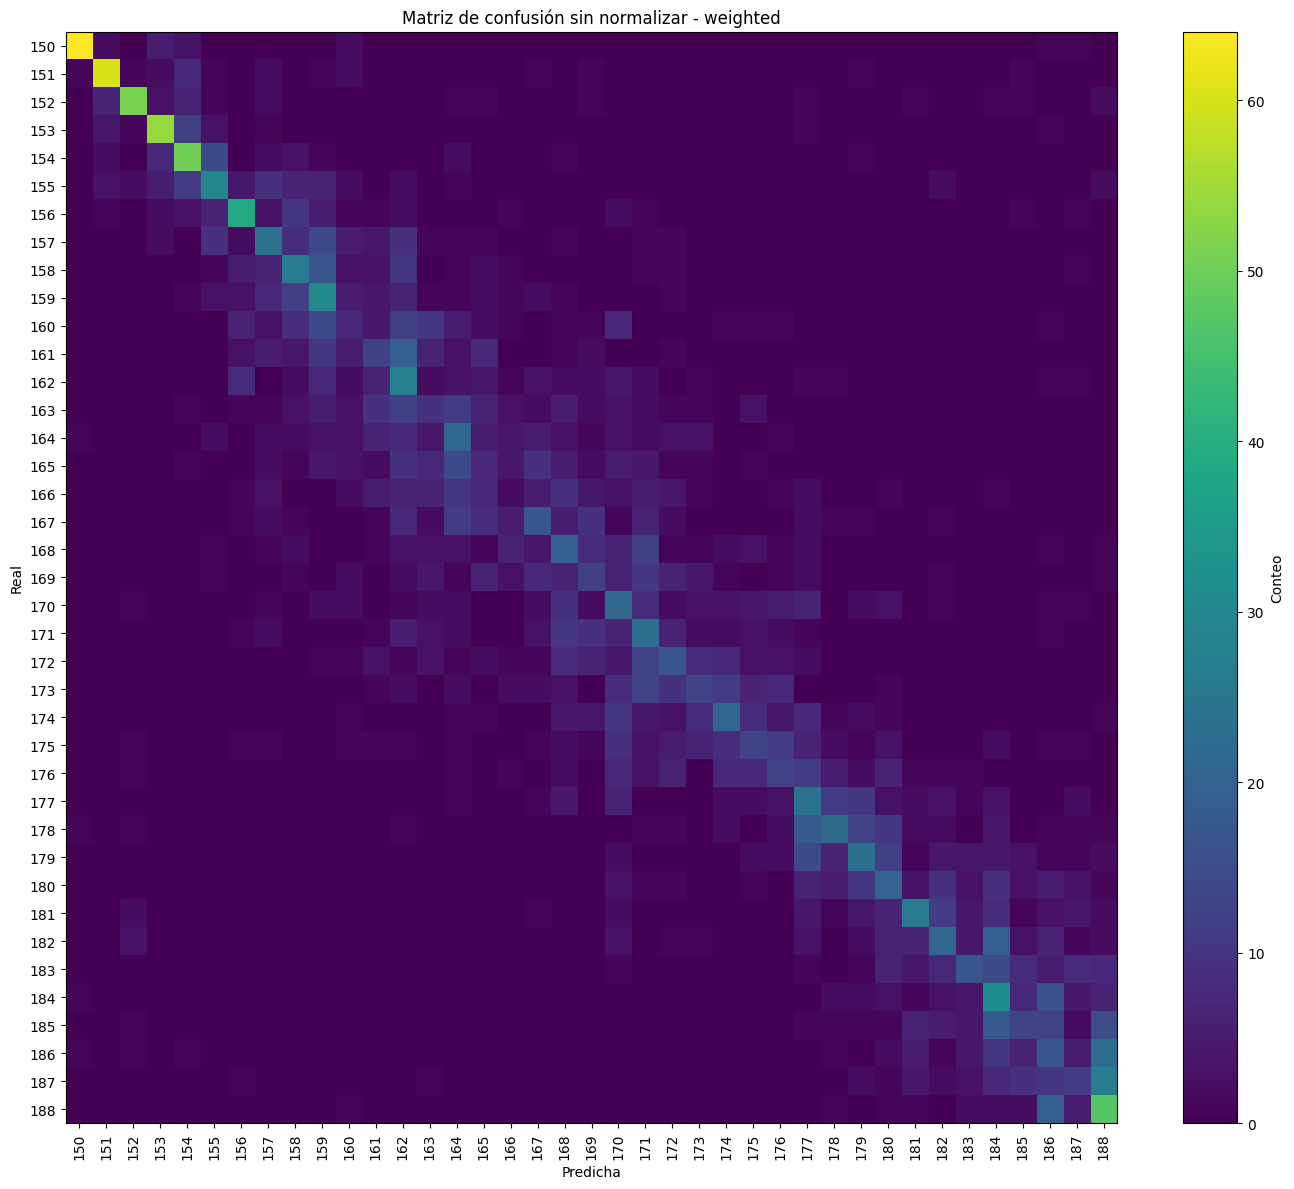

In [25]:
# =========================
# Matriz de confusión del mejor método elegido manualmente
# =========================

# Cambia aquí si prefieres meta_lr, meta_mlp o weighted.
FINAL_METHOD_FOR_ANALYSIS = 'weighted'

if FINAL_METHOD_FOR_ANALYSIS == 'meta_lr':
    final_test_preds = meta_test_preds
elif FINAL_METHOD_FOR_ANALYSIS == 'meta_mlp':
    final_test_preds = meta_mlp_test_preds
else:
    final_test_preds = preds_test_weighted

cm = confusion_matrix(y_test, final_test_preds, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=[idx_to_decade[i] for i in range(NUM_CLASSES)], columns=[idx_to_decade[i] for i in range(NUM_CLASSES)])
print('Método para análisis:', FINAL_METHOD_FOR_ANALYSIS)
print_metrics('Final test', metrics_from_preds(y_test, final_test_preds))
display(cm_df)

plt.figure(figsize=(14, 12))
plt.imshow(cm, aspect='auto')
plt.title(f'Matriz de confusión sin normalizar - {FINAL_METHOD_FOR_ANALYSIS}')
plt.xlabel('Predicha')
plt.ylabel('Real')
plt.xticks(np.arange(NUM_CLASSES), [idx_to_decade[i] for i in range(NUM_CLASSES)], rotation=90)
plt.yticks(np.arange(NUM_CLASSES), [idx_to_decade[i] for i in range(NUM_CLASSES)])
plt.colorbar(label='Conteo')
plt.tight_layout()
plt.show()


## Submission con modelos entrenados en el split

Esta submission usa los modelos entrenados en `train_df` y el stacking elegido usando `val_df`. No entrena con `eval.csv`.

In [26]:
# =========================
# Dataset eval RoBERTa y TF-IDF transforms
# =========================

eval_df = pd.read_csv(EVAL_PATH)
assert 'id' in eval_df.columns and TEXT_COL in eval_df.columns
eval_df[TEXT_COL] = eval_df[TEXT_COL].fillna('').astype(str)
eval_texts = eval_df[TEXT_COL].tolist()
print('eval_df:', eval_df.shape)

X1_eval = sp.hstack([tfidf1_char.transform(eval_texts), tfidf1_word.transform(eval_texts)], format='csr', dtype=np.float32)
X2_eval = sp.hstack([tfidf2_char.transform(eval_texts), tfidf2_char_wb.transform(eval_texts)], format='csr', dtype=np.float32)

class EvalSparseDataset(Dataset):
    def __init__(self, n):
        self.indices = np.arange(n)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        return {'idx': int(self.indices[idx])}

def eval_sparse_collate_fn(batch):
    return {'indices': torch.tensor([b['idx'] for b in batch], dtype=torch.long)}

eval_sparse_loader = DataLoader(EvalSparseDataset(len(eval_df)), batch_size=BATCH_SIZE_TFIDF, shuffle=False, collate_fn=eval_sparse_collate_fn, num_workers=0)

class EvalRobertaDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = crop_text_eval(self.texts[idx], mode='center')
        enc = tokenizer(text, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors=None)
        return {
            'input_ids': torch.tensor(enc['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(enc['attention_mask'], dtype=torch.long),
        }

def eval_roberta_collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
    }

eval_roberta_loader = DataLoader(EvalRobertaDataset(eval_texts), batch_size=BATCH_SIZE_ROBERTA, shuffle=False, collate_fn=eval_roberta_collate_fn, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))


eval_df: (3490, 2)


In [27]:
# =========================
# Predicciones en eval
# =========================

@torch.no_grad()
def predict_tfidf_probs_eval(model, X_matrix, loader):
    model.eval()
    probs_all = []
    for batch in tqdm(loader, desc='TF-IDF eval predicting', leave=False):
        idx = batch['indices'].numpy()
        Xb = csr_batch_to_torch_sparse(X_matrix[idx], device=DEVICE)
        logits = model(Xb)
        probs = torch.softmax(logits, dim=1)
        probs_all.append(probs.detach().cpu().numpy())
    return np.vstack(probs_all)

@torch.no_grad()
def predict_roberta_probs_eval(model, loader):
    model.eval()
    probs_all = []
    for batch in tqdm(loader, desc='RoBERTa eval predicting', leave=False):
        input_ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type='cuda', enabled=(DEVICE.type == 'cuda')):
            logits = model(input_ids, attention_mask)
            probs = torch.softmax(logits, dim=1)
        probs_all.append(probs.detach().cpu().numpy())
    return np.vstack(probs_all)

probs1_eval = predict_tfidf_probs_eval(model_tfidf1, X1_eval, eval_sparse_loader)
probs2_eval = predict_tfidf_probs_eval(model_tfidf2, X2_eval, eval_sparse_loader)
probs_r_eval = predict_roberta_probs_eval(model_roberta, eval_roberta_loader)

print('probs1_eval:', probs1_eval.shape)
print('probs2_eval:', probs2_eval.shape)
print('probs_r_eval:', probs_r_eval.shape)


probs1_eval: (3490, 39)
probs2_eval: (3490, 39)
probs_r_eval: (3490, 39)


In [28]:
# =========================
# Crear submission del método elegido
# =========================

SUBMISSION_PATH = 'submission_stacking_three_models.csv'
FINAL_METHOD_FOR_SUBMISSION = FINAL_METHOD_FOR_ANALYSIS

if FINAL_METHOD_FOR_SUBMISSION == 'meta_lr':
    meta_X_eval = build_meta_features(probs1_eval, probs2_eval, probs_r_eval)
    pred_eval_idx = meta_lr.predict(meta_X_eval)
elif FINAL_METHOD_FOR_SUBMISSION == 'meta_mlp':
    meta_X_eval = build_meta_features(probs1_eval, probs2_eval, probs_r_eval)
    pred_eval_idx = meta_mlp.predict(meta_X_eval)
else:
    probs_eval = best_w[0] * probs1_eval + best_w[1] * probs2_eval + best_w[2] * probs_r_eval
    pred_eval_idx = probs_eval.argmax(axis=1)

answers = [idx_to_decade[int(i)] for i in pred_eval_idx]
submission = pd.DataFrame({'id': eval_df['id'].values, 'answer': answers})
submission.to_csv(SUBMISSION_PATH, index=False)
print('Submission guardada:', SUBMISSION_PATH)
print('Método usado:', FINAL_METHOD_FOR_SUBMISSION)
print('Shape:', submission.shape)
display(submission.head())
display(submission['answer'].value_counts().sort_index())


Submission guardada: submission_stacking_three_models.csv
Método usado: weighted
Shape: (3490, 2)


,id,answer
0,0,176
1,1,187
2,2,150
3,3,171
4,4,153


answer
150     74
151     79
152     85
153    109
154     96
155     82
156     89
157     82
158     93
159    144
160     59
161     70
162    166
163     95
164     91
165     84
166     29
167     86
168    114
169     62
170    121
171    128
172     66
173     77
174     89
175     60
176     66
177    109
178     59
179     65
180    102
181     63
182     90
183     43
184    148
185     68
186    112
187     54
188    181
Name: count, dtype: int64

## Opción final: reentrenar base models con todo train.csv

Esta sección es opcional y costosa. Entrena modelos base con todo `train.csv` usando los hiperparámetros definidos. El meta-modelo/pesos se mantienen aprendidos desde validation, sin usar `eval.csv`.

In [29]:
RUN_FULL_DATA_TRAINING = False
print('RUN_FULL_DATA_TRAINING:', RUN_FULL_DATA_TRAINING)


RUN_FULL_DATA_TRAINING: False


In [30]:
# =========================
# Full-data training opcional
# =========================

if RUN_FULL_DATA_TRAINING:
    full_texts = df[TEXT_COL].tolist()
    y_full = df['label_idx'].values.astype(np.int64)

    print('Ajustando TF-IDF full-data A...')
    full_tfidf1_char = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), min_df=MIN_DF, max_df=MAX_DF, max_features=TFIDF1_CHAR_MAX_FEATURES, sublinear_tf=True, lowercase=False, strip_accents=None, dtype=np.float32)
    full_tfidf1_word = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=MIN_DF, max_df=MAX_DF, max_features=TFIDF1_WORD_MAX_FEATURES, sublinear_tf=True, lowercase=False, strip_accents=None, token_pattern=r'(?u)\b\w+\b', dtype=np.float32)
    X1_full = sp.hstack([full_tfidf1_char.fit_transform(full_texts), full_tfidf1_word.fit_transform(full_texts)], format='csr', dtype=np.float32)

    print('Ajustando TF-IDF full-data B...')
    full_tfidf2_char = TfidfVectorizer(analyzer='char', ngram_range=(3, 7), min_df=MIN_DF, max_df=MAX_DF, max_features=TFIDF2_CHAR_MAX_FEATURES, sublinear_tf=True, lowercase=False, strip_accents=None, dtype=np.float32)
    full_tfidf2_char_wb = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 6), min_df=MIN_DF, max_df=MAX_DF, max_features=TFIDF2_CHAR_WB_MAX_FEATURES, sublinear_tf=True, lowercase=False, strip_accents=None, dtype=np.float32)
    X2_full = sp.hstack([full_tfidf2_char.fit_transform(full_texts), full_tfidf2_char_wb.fit_transform(full_texts)], format='csr', dtype=np.float32)

    full_sparse_loader = DataLoader(SparseIndexDataset(y_full), batch_size=BATCH_SIZE_TFIDF, shuffle=True, collate_fn=sparse_collate_fn, num_workers=0)
    old_train_sparse_loader = train_sparse_loader
    train_sparse_loader = full_sparse_loader

    model_tfidf1_full, _, _ = train_tfidf_model(X1_full, X1_full, X1_full.shape[1], name='TFIDF_A_FULL')
    model_tfidf2_full, _, _ = train_tfidf_model(X2_full, X2_full, X2_full.shape[1], name='TFIDF_B_FULL')
    train_sparse_loader = old_train_sparse_loader

    print('Full-data TF-IDF models entrenados. Para ahorrar tiempo, el full-data RoBERTa no se ejecuta en esta plantilla.')
    print('Puedes correr una versión full-data de RoBERTa duplicando la sección de RoBERTa con df completo.')
